# Part II: Polynomial Regression with Two Features

## Objective

Capture nonlinear and interaction effects using polynomial feature engineering and an explicit bias term:

$$\hat{L} = X \cdot w + b$$

### Feature Map

Construct the design matrix using the following features (do not include a constant column of ones):

$$X = [ M, T, M^2, M \cdot T ]$$

---

## Required Tasks

1. **Dataset visualization**: plot L vs M and encode T (color or marker size).
2. **Feature engineering**: build X with NumPy vectorization.
3. **Loss and gradients (vectorized)**: implement MSE and gradients w.r.t. both w and b.
4. **Gradient descent + convergence**: train and plot loss vs iterations.
5. **Feature selection experiment (mandatory)**: compare M1, M2, M3 models.
6. **Cost vs interaction (mandatory)**: vary w_MT and plot cost.
7. **Inference demo (mandatory)**: predict luminosity for a new star.

## Task 1: Dataset and Visualization

**Dataset (Part II - two features):**
- M: stellar mass (in units of solar mass, M⊙)
- T: effective stellar temperature (Kelvin, K)
- L: stellar luminosity (in units of solar luminosity, L⊙)

Plot L vs M and encode T using color or marker size.

Number of examples: m = 10
Stellar Mass M (M☉): [0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4]
Temperature T (K): [3800 4400 5800 6400 6900 7400 7900 8300 8800 9200]
Stellar Luminosity L (L☉): [ 0.15  0.35  1.    2.3   4.1   7.   11.2  17.5  25.   35.  ]


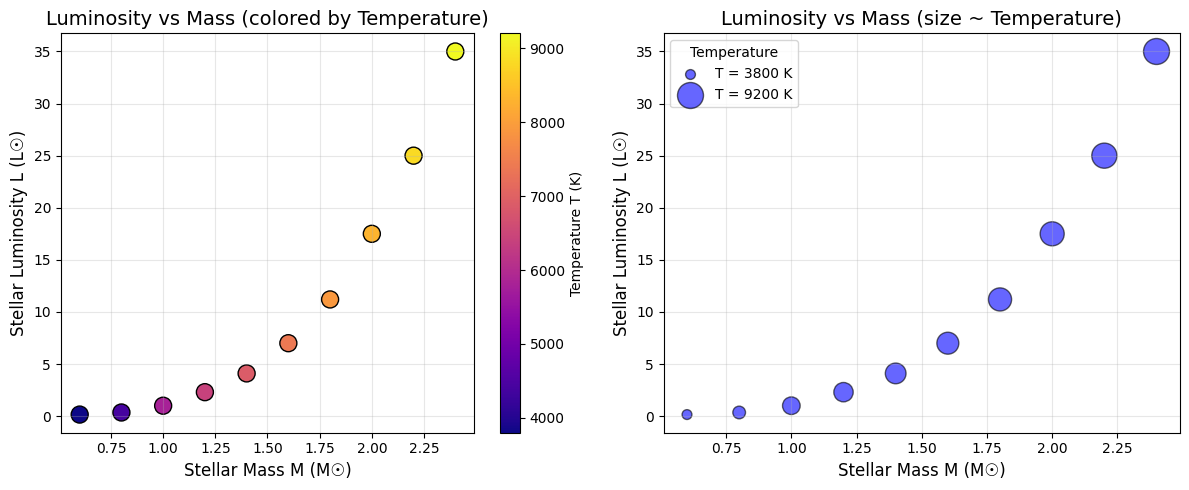

In [1]:
# Task 1: Dataset and Visualization
import numpy as np
import matplotlib.pyplot as plt

# Dataset (Part II - two features)
# M: stellar mass (in units of solar mass, M⊙)
# T: effective stellar temperature (Kelvin, K)
# L: stellar luminosity (in units of solar luminosity, L⊙)

M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

# Number of examples
m = len(M)
print(f"Number of examples: m = {m}")
print(f"Stellar Mass M (M☉): {M}")
print(f"Temperature T (K): {T}")
print(f"Stellar Luminosity L (L☉): {L}")

# Plot L vs M with T encoded as color
plt.figure(figsize=(12, 5))

# Subplot 1: L vs M with T as color
plt.subplot(1, 2, 1)
scatter = plt.scatter(M, L, c=T, cmap='plasma', s=150, edgecolors='black')
plt.colorbar(scatter, label='Temperature T (K)')
plt.xlabel("Stellar Mass M (M☉)", fontsize=12)
plt.ylabel("Stellar Luminosity L (L☉)", fontsize=12)
plt.title("Luminosity vs Mass (colored by Temperature)", fontsize=14)
plt.grid(True, alpha=0.3)

# Subplot 2: L vs M with T as marker size
plt.subplot(1, 2, 2)
# Normalize T for marker size (scale to reasonable range)
sizes = (T - T.min()) / (T.max() - T.min()) * 300 + 50
plt.scatter(M, L, s=sizes, c='blue', alpha=0.6, edgecolors='black')
plt.xlabel("Stellar Mass M (M☉)", fontsize=12)
plt.ylabel("Stellar Luminosity L (L☉)", fontsize=12)
plt.title("Luminosity vs Mass (size ~ Temperature)", fontsize=14)
plt.grid(True, alpha=0.3)

# Add legend for size
for t_val, size_val in [(T.min(), 50), (T.max(), 350)]:
    plt.scatter([], [], s=size_val, c='blue', alpha=0.6, edgecolors='black', 
                label=f'T = {t_val:.0f} K')
plt.legend(title='Temperature', loc='upper left')

plt.tight_layout()
plt.show()

### Observations on the Dataset

**Relationship Patterns:**
- There is a strong **positive correlation** between stellar mass (M) and luminosity (L).
- The relationship is clearly **non-linear** — luminosity increases much faster than mass.
- Temperature (T) also increases with mass, which is consistent with stellar physics: more massive stars have higher surface temperatures.

**Physical Interpretation:**
- More massive stars have higher core pressures and temperatures, leading to:
  1. Faster nuclear fusion rates → higher luminosity
  2. Higher surface temperatures → bluer color
- The data suggests that both M and T contribute to determining L, and there may be **interaction effects** between these features.

**Justification for Polynomial Features:**
- The curvature in the L vs M relationship suggests we need polynomial terms (like $M^2$).
- The correlation between M and T suggests an **interaction term** ($M \times T$) might capture combined effects.

## Task 2: Feature Engineering

Build the design matrix X using NumPy vectorization with the following features:
- M (stellar mass)
- T (stellar temperature)
- M² (mass squared)
- M·T (mass-temperature interaction)

**Do not include a constant column of ones** (the bias b is handled separately).

In [2]:
# Task 2: Feature Engineering

def build_feature_matrix(M, T, model_type='M3'):
    """
    Build design matrix X with polynomial features using NumPy vectorization.
    
    Feature maps:
    - M1: X = [M, T]                    (2 features)
    - M2: X = [M, T, M²]                (3 features)
    - M3: X = [M, T, M², M·T]           (4 features) - Full model
    
    Parameters:
    -----------
    M : np.ndarray
        Stellar mass values
    T : np.ndarray
        Stellar temperature values
    model_type : str
        'M1', 'M2', or 'M3' to select feature set
    
    Returns:
    --------
    X : np.ndarray
        Design matrix (m x n), where n depends on model_type
    feature_names : list
        Names of the features for interpretation
    """
    if model_type == 'M1':
        # Model 1: Linear features only [M, T]
        X = np.column_stack([M, T])
        feature_names = ['M', 'T']
    
    elif model_type == 'M2':
        # Model 2: Add quadratic term [M, T, M²]
        X = np.column_stack([M, T, M**2])
        feature_names = ['M', 'T', 'M²']
    
    elif model_type == 'M3':
        # Model 3: Full polynomial with interaction [M, T, M², M·T]
        X = np.column_stack([M, T, M**2, M * T])
        feature_names = ['M', 'T', 'M²', 'M·T']
    
    else:
        raise ValueError(f"Unknown model_type: {model_type}. Use 'M1', 'M2', or 'M3'.")
    
    return X, feature_names


# Build feature matrices for all three models
X_M1, features_M1 = build_feature_matrix(M, T, 'M1')
X_M2, features_M2 = build_feature_matrix(M, T, 'M2')
X_M3, features_M3 = build_feature_matrix(M, T, 'M3')

print("=" * 60)
print("Feature Engineering Results")
print("=" * 60)

print(f"\nModel M1 - Features: {features_M1}")
print(f"  Shape: {X_M1.shape}")
print(f"  First 3 rows:\n{X_M1[:3]}")

print(f"\nModel M2 - Features: {features_M2}")
print(f"  Shape: {X_M2.shape}")
print(f"  First 3 rows:\n{X_M2[:3]}")

print(f"\nModel M3 - Features: {features_M3}")
print(f"  Shape: {X_M3.shape}")
print(f"  First 3 rows:\n{X_M3[:3]}")

Feature Engineering Results

Model M1 - Features: ['M', 'T']
  Shape: (10, 2)
  First 3 rows:
[[6.0e-01 3.8e+03]
 [8.0e-01 4.4e+03]
 [1.0e+00 5.8e+03]]

Model M2 - Features: ['M', 'T', 'M²']
  Shape: (10, 3)
  First 3 rows:
[[6.0e-01 3.8e+03 3.6e-01]
 [8.0e-01 4.4e+03 6.4e-01]
 [1.0e+00 5.8e+03 1.0e+00]]

Model M3 - Features: ['M', 'T', 'M²', 'M·T']
  Shape: (10, 4)
  First 3 rows:
[[6.00e-01 3.80e+03 3.60e-01 2.28e+03]
 [8.00e-01 4.40e+03 6.40e-01 3.52e+03]
 [1.00e+00 5.80e+03 1.00e+00 5.80e+03]]


In [3]:
# Feature Scaling Function (important for gradient descent convergence)

def feature_scale(X):
    """
    Standardize each feature to have mean 0 and standard deviation 1.
    
    Formula: X_scaled = (X - mean) / std
    
    Parameters:
    -----------
    X : np.ndarray, shape (m, n)
        Design matrix
    
    Returns:
    --------
    X_scaled : np.ndarray, shape (m, n)
        Scaled design matrix
    means : np.ndarray, shape (n,)
        Mean of each feature
    stds : np.ndarray, shape (n,)
        Standard deviation of each feature
    """
    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=0)
    # Avoid division by zero
    stds = np.where(stds == 0, 1, stds)
    X_scaled = (X - means) / stds
    return X_scaled, means, stds


# Scale the full model (M3) for demonstration
X_M3_scaled, X_M3_means, X_M3_stds = feature_scale(X_M3)

print("Feature Scaling for Model M3:")
print(f"  Feature means: {X_M3_means}")
print(f"  Feature stds:  {X_M3_stds}")
print(f"\nScaled X_M3 (first 3 rows):\n{X_M3_scaled[:3]}")
print(f"\nVerification - Scaled means: {X_M3_scaled.mean(axis=0)}")
print(f"Verification - Scaled stds:  {X_M3_scaled.std(axis=0)}")

Feature Scaling for Model M3:
  Feature means: [1.5000e+00 6.8900e+03 2.5800e+00 1.1304e+04]
  Feature stds:  [5.74456265e-01 1.71548827e+03 1.74770707e+00 6.37191211e+03]

Scaled X_M3 (first 3 rows):
[[-1.5666989  -1.80123645 -1.27023575 -1.41621539]
 [-1.21854359 -1.4514818  -1.11002584 -1.22161132]
 [-0.87038828 -0.63538762 -0.90404166 -0.86379095]]

Verification - Scaled means: [-3.33066907e-16  6.66133815e-17  2.44249065e-16  4.44089210e-17]
Verification - Scaled stds:  [1. 1. 1. 1.]


## Task 3: Loss and Gradients (Vectorized)

Implement using NumPy vectorization:
- **MSE Loss**: $J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{L}_i - L_i)^2$
- **Gradients**: $\frac{\partial J}{\partial w}$ and $\frac{\partial J}{\partial b}$

Where: $\hat{L} = X \cdot w + b$

In [4]:
# Task 3: Loss and Gradients (Vectorized)

def predict_poly(X, w, b):
    """
    Vectorized prediction function for polynomial regression.
    
    Model: L_hat = X @ w + b
    
    Parameters:
    -----------
    X : np.ndarray, shape (m, n)
        Design matrix (feature-engineered)
    w : np.ndarray, shape (n,)
        Weight vector
    b : float
        Bias term
    
    Returns:
    --------
    L_hat : np.ndarray, shape (m,)
        Predicted luminosity values
    """
    return X @ w + b


def compute_cost_poly(X, L, w, b):
    """
    Compute the Mean Squared Error (MSE) cost function (vectorized).
    
    J(w, b) = (1 / 2m) * (L_hat - L)ᵀ(L_hat - L)
    
    Parameters:
    -----------
    X : np.ndarray, shape (m, n)
        Design matrix
    L : np.ndarray, shape (m,)
        True luminosity values
    w : np.ndarray, shape (n,)
        Weight vector
    b : float
        Bias term
    
    Returns:
    --------
    cost : float
        The MSE cost value
    """
    m = X.shape[0]
    L_hat = predict_poly(X, w, b)
    errors = L_hat - L
    cost = (errors @ errors) / (2 * m)
    return cost


def compute_gradients_poly(X, L, w, b):
    """
    Compute gradients of J with respect to w and b (vectorized).
    
    Vectorized formulas:
        ∂J/∂w = (1/m) * Xᵀ(L_hat - L)
        ∂J/∂b = (1/m) * Σ(L_hat - L)
    
    Parameters:
    -----------
    X : np.ndarray, shape (m, n)
        Design matrix
    L : np.ndarray, shape (m,)
        True luminosity values
    w : np.ndarray, shape (n,)
        Weight vector
    b : float
        Bias term
    
    Returns:
    --------
    dj_dw : np.ndarray, shape (n,)
        Gradient with respect to w
    dj_db : float
        Gradient with respect to b
    """
    m = X.shape[0]
    L_hat = predict_poly(X, w, b)
    errors = L_hat - L
    
    # Vectorized gradient computation
    dj_dw = (X.T @ errors) / m
    dj_db = np.sum(errors) / m
    
    return dj_dw, dj_db


# Test the functions with the full model (M3)
print("=" * 60)
print("Testing Loss and Gradient Functions")
print("=" * 60)

# Initialize parameters
n_features = X_M3_scaled.shape[1]
w_test = np.zeros(n_features)
b_test = 0.0

# Test prediction
L_pred_test = predict_poly(X_M3_scaled, w_test, b_test)
print(f"\nTest predictions (first 5) with w=0, b=0: {L_pred_test[:5]}")

# Test cost
cost_test = compute_cost_poly(X_M3_scaled, L, w_test, b_test)
print(f"Cost with w=0, b=0: {cost_test:.4f}")

# Test gradients
dj_dw_test, dj_db_test = compute_gradients_poly(X_M3_scaled, L, w_test, b_test)
print(f"\nGradients at w=0, b=0:")
print(f"  ∂J/∂w = {dj_dw_test}")
print(f"  ∂J/∂b = {dj_db_test:.4f}")

Testing Loss and Gradient Functions

Test predictions (first 5) with w=0, b=0: [0. 0. 0. 0. 0.]
Cost with w=0, b=0: 117.6967

Gradients at w=0, b=0:
  ∂J/∂w = [-10.41506616  -9.59761737 -10.99417651 -10.71881702]
  ∂J/∂b = -10.3600


## Task 4: Gradient Descent + Convergence

Train the model and plot **loss vs iterations**.

Training Polynomial Regression Model (M3)
Iteration     0: cost = 72.438211
Iteration   100: cost = 3.286783
Iteration   200: cost = 1.686453
Iteration   300: cost = 1.198722
Iteration   400: cost = 1.040189
Iteration   500: cost = 0.979338
Iteration   600: cost = 0.947745
Iteration   700: cost = 0.925177
Iteration   800: cost = 0.905646
Iteration   900: cost = 0.887370
Iteration   999: cost = 0.869987

Training Complete!
Final cost: 0.869987
Learned weights: [-1.89483909 -7.86303363 13.897731    6.39170928]
Learned bias: 10.3600


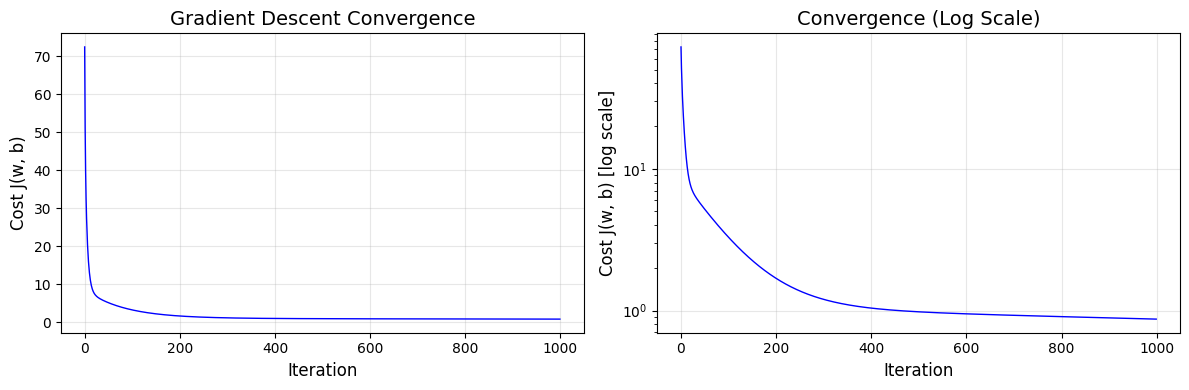


Prediction Quality:
Star   Actual L     Predicted L  Error       
------------------------------------------
1      0.15         0.79         +0.64       
2      0.35         0.85         +0.50       
3      1.00         -1.08        -2.08       
4      2.30         0.89         -1.41       
5      4.10         4.06         -0.04       
6      7.00         8.07         +1.07       
7      11.20        12.91        +1.71       
8      17.50        18.85        +1.35       
9      25.00        25.35        +0.35       
10     35.00        32.90        -2.10       


In [5]:
# Task 4: Gradient Descent + Convergence

def gradient_descent_poly(X, L, w_init, b_init, learning_rate, num_iterations, verbose=True):
    """
    Gradient descent for polynomial regression.
    
    Parameters:
    -----------
    X : np.ndarray, shape (m, n)
        Design matrix (scaled)
    L : np.ndarray, shape (m,)
        True luminosity values
    w_init : np.ndarray, shape (n,)
        Initial weight vector
    b_init : float
        Initial bias
    learning_rate : float
        Learning rate (alpha)
    num_iterations : int
        Number of iterations
    verbose : bool
        Print progress every 10% of iterations
    
    Returns:
    --------
    w : np.ndarray
        Learned weights
    b : float
        Learned bias
    cost_history : list
        Cost at each iteration for convergence analysis
    """
    w = w_init.copy()
    b = b_init
    cost_history = []
    
    for i in range(num_iterations):
        # Compute gradients
        dj_dw, dj_db = compute_gradients_poly(X, L, w, b)
        
        # Update parameters
        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db
        
        # Track cost
        cost = compute_cost_poly(X, L, w, b)
        cost_history.append(cost)
        
        # Print progress
        if verbose and (i % max(1, num_iterations // 10) == 0 or i == num_iterations - 1):
            print(f"Iteration {i:5d}: cost = {cost:.6f}")
    
    return w, b, cost_history


# Train the model using the full feature set (M3) with scaled features
print("=" * 60)
print("Training Polynomial Regression Model (M3)")
print("=" * 60)

# Initialize parameters
n_features = X_M3_scaled.shape[1]
w_init = np.zeros(n_features)
b_init = 0.0

# Hyperparameters
learning_rate = 0.1
num_iterations = 1000

# Train!
w_M3, b_M3, cost_history_M3 = gradient_descent_poly(
    X_M3_scaled, L, w_init, b_init, learning_rate, num_iterations
)

print(f"\n{'=' * 60}")
print("Training Complete!")
print(f"{'=' * 60}")
print(f"Final cost: {cost_history_M3[-1]:.6f}")
print(f"Learned weights: {w_M3}")
print(f"Learned bias: {b_M3:.4f}")

# Plot convergence
plt.figure(figsize=(12, 4))

# Plot 1: Full convergence curve
plt.subplot(1, 2, 1)
plt.plot(cost_history_M3, 'b-', linewidth=1)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cost J(w, b)", fontsize=12)
plt.title("Gradient Descent Convergence", fontsize=14)
plt.grid(True, alpha=0.3)

# Plot 2: Log scale to see fine convergence
plt.subplot(1, 2, 2)
plt.semilogy(cost_history_M3, 'b-', linewidth=1)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cost J(w, b) [log scale]", fontsize=12)
plt.title("Convergence (Log Scale)", fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show predictions vs actual
L_pred_M3 = predict_poly(X_M3_scaled, w_M3, b_M3)
print(f"\nPrediction Quality:")
print(f"{'Star':<6} {'Actual L':<12} {'Predicted L':<12} {'Error':<12}")
print("-" * 42)
for i in range(len(L)):
    error = L_pred_M3[i] - L[i]
    print(f"{i+1:<6} {L[i]:<12.2f} {L_pred_M3[i]:<12.2f} {error:<+12.2f}")

## Task 5: Feature Selection Experiment (Mandatory)

Compare three models with different feature sets:

| Model | Features |
|-------|----------|
| **M1** | X = [M, T] |
| **M2** | X = [M, T, M²] |
| **M3** | X = [M, T, M², M·T] |

For each model, report:
- Final loss
- Learned parameters
- Predicted vs actual plot (inline)

FEATURE SELECTION EXPERIMENT: Comparing M1, M2, M3 Models

MODEL M1: Features = [M, T]
Final cost: 3.904740
Learned weights: [ 24.90749961 -14.81682089]
Learned bias: 10.3600

MODEL M2: Features = [M, T, M²]
Final cost: 0.876212
Learned weights: [ 0.19450813 -7.09375395 17.47397219]
Learned bias: 10.3600

MODEL M3: Features = [M, T, M², M·T]
Final cost: 0.869987
Learned weights: [-1.89483909 -7.86303363 13.897731    6.39170928]
Learned bias: 10.3600

MODEL COMPARISON SUMMARY
Model      Features                  Final Cost      Improvement    
----------------------------------------------------------------------
M1         [M, T]                    3.904740        ---            
M2         [M, T, M²]                0.876212        77.6%          
M3         [M, T, M², M·T]           0.869987        77.7%          


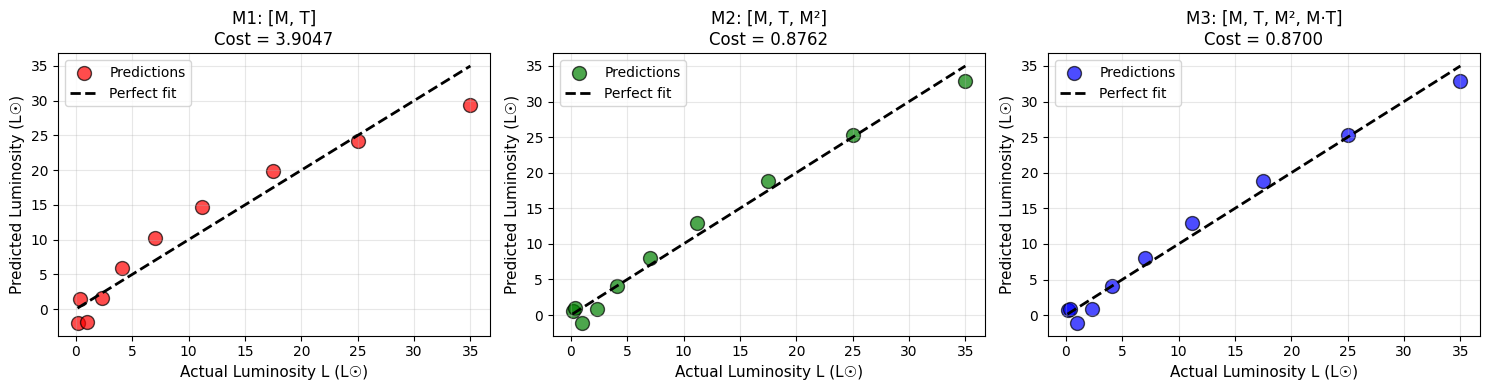

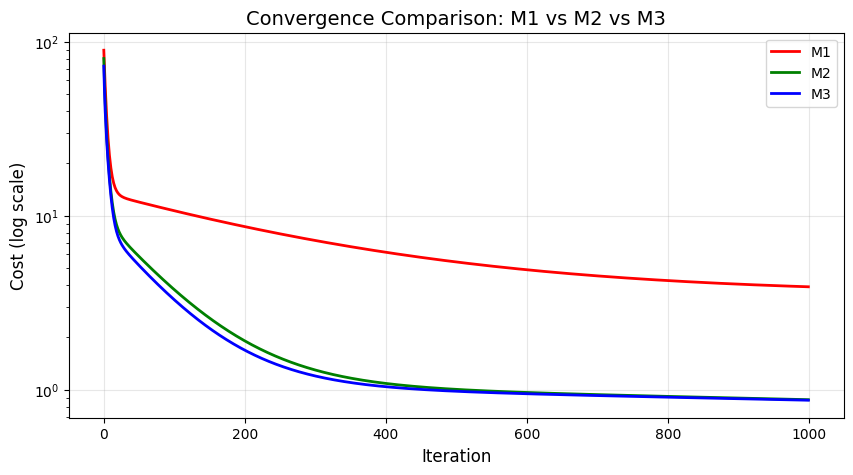

In [6]:
# Task 5: Feature Selection Experiment (Mandatory)

print("=" * 70)
print("FEATURE SELECTION EXPERIMENT: Comparing M1, M2, M3 Models")
print("=" * 70)

# Training hyperparameters
learning_rate = 0.1
num_iterations = 1000

# Store results for comparison
results = {}

# ============================================================
# Model M1: X = [M, T]
# ============================================================
print("\n" + "=" * 50)
print("MODEL M1: Features = [M, T]")
print("=" * 50)

X_M1_scaled, X_M1_means, X_M1_stds = feature_scale(X_M1)
w_init_M1 = np.zeros(X_M1_scaled.shape[1])
w_M1, b_M1, cost_history_M1 = gradient_descent_poly(
    X_M1_scaled, L, w_init_M1, 0.0, learning_rate, num_iterations, verbose=False
)
L_pred_M1 = predict_poly(X_M1_scaled, w_M1, b_M1)

results['M1'] = {
    'w': w_M1, 'b': b_M1, 
    'final_cost': cost_history_M1[-1],
    'predictions': L_pred_M1,
    'cost_history': cost_history_M1
}

print(f"Final cost: {cost_history_M1[-1]:.6f}")
print(f"Learned weights: {w_M1}")
print(f"Learned bias: {b_M1:.4f}")

# ============================================================
# Model M2: X = [M, T, M²]
# ============================================================
print("\n" + "=" * 50)
print("MODEL M2: Features = [M, T, M²]")
print("=" * 50)

X_M2_scaled, X_M2_means, X_M2_stds = feature_scale(X_M2)
w_init_M2 = np.zeros(X_M2_scaled.shape[1])
w_M2, b_M2, cost_history_M2 = gradient_descent_poly(
    X_M2_scaled, L, w_init_M2, 0.0, learning_rate, num_iterations, verbose=False
)
L_pred_M2 = predict_poly(X_M2_scaled, w_M2, b_M2)

results['M2'] = {
    'w': w_M2, 'b': b_M2,
    'final_cost': cost_history_M2[-1],
    'predictions': L_pred_M2,
    'cost_history': cost_history_M2
}

print(f"Final cost: {cost_history_M2[-1]:.6f}")
print(f"Learned weights: {w_M2}")
print(f"Learned bias: {b_M2:.4f}")

# ============================================================
# Model M3: X = [M, T, M², M·T]
# ============================================================
print("\n" + "=" * 50)
print("MODEL M3: Features = [M, T, M², M·T]")
print("=" * 50)

# Use already trained M3 from Task 4
results['M3'] = {
    'w': w_M3, 'b': b_M3,
    'final_cost': cost_history_M3[-1],
    'predictions': L_pred_M3,
    'cost_history': cost_history_M3
}

print(f"Final cost: {cost_history_M3[-1]:.6f}")
print(f"Learned weights: {w_M3}")
print(f"Learned bias: {b_M3:.4f}")

# ============================================================
# Comparison Summary
# ============================================================
print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Model':<10} {'Features':<25} {'Final Cost':<15} {'Improvement':<15}")
print("-" * 70)

base_cost = results['M1']['final_cost']
for model_name, model_data in results.items():
    if model_name == 'M1':
        features = "[M, T]"
        improvement = "---"
    elif model_name == 'M2':
        features = "[M, T, M²]"
        improvement = f"{(1 - model_data['final_cost']/base_cost)*100:.1f}%"
    else:
        features = "[M, T, M², M·T]"
        improvement = f"{(1 - model_data['final_cost']/base_cost)*100:.1f}%"
    
    print(f"{model_name:<10} {features:<25} {model_data['final_cost']:<15.6f} {improvement:<15}")

# ============================================================
# Visualization: Predicted vs Actual for all models
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = ['M1', 'M2', 'M3']
titles = ['M1: [M, T]', 'M2: [M, T, M²]', 'M3: [M, T, M², M·T]']
colors = ['red', 'green', 'blue']

for ax, model, title, color in zip(axes, models, titles, colors):
    L_pred = results[model]['predictions']
    final_cost = results[model]['final_cost']
    
    # Scatter plot
    ax.scatter(L, L_pred, c=color, s=100, alpha=0.7, edgecolors='black', label='Predictions')
    
    # Perfect prediction line
    ax.plot([L.min(), L.max()], [L.min(), L.max()], 'k--', linewidth=2, label='Perfect fit')
    
    ax.set_xlabel("Actual Luminosity L (L☉)", fontsize=11)
    ax.set_ylabel("Predicted Luminosity (L☉)", fontsize=11)
    ax.set_title(f"{title}\nCost = {final_cost:.4f}", fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Convergence comparison
plt.figure(figsize=(10, 5))
for model, color in zip(models, colors):
    plt.semilogy(results[model]['cost_history'], label=model, linewidth=2, color=color)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cost (log scale)", fontsize=12)
plt.title("Convergence Comparison: M1 vs M2 vs M3", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Task 6: Cost vs Interaction (Mandatory)

For the full model (M3), vary the interaction coefficient $w_{MT}$ across a reasonable range while keeping the other parameters fixed (e.g., at their trained values).

- Plot **cost vs $w_{MT}$**
- Explain what it indicates about **interaction importance**

COST vs INTERACTION COEFFICIENT ANALYSIS


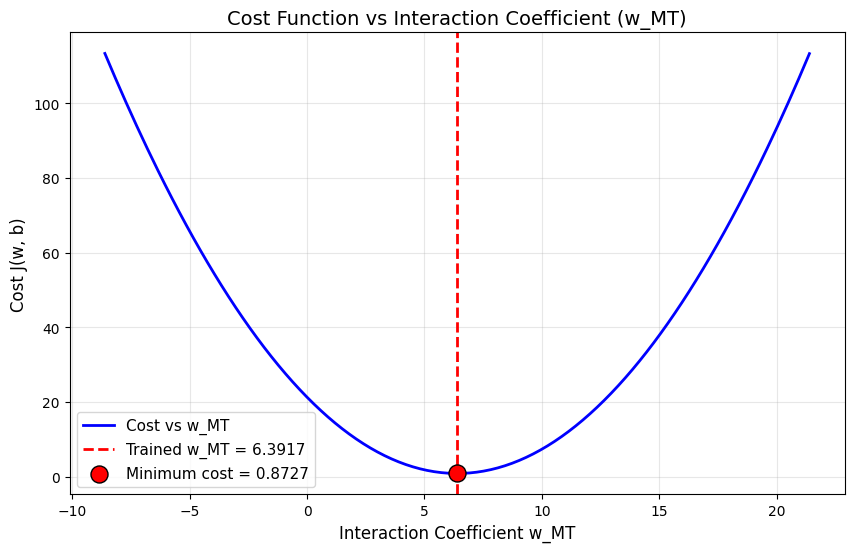


Analysis Results:
  Optimal w_MT from training: 6.3917
  Minimum cost: 0.872714
  Cost sensitivity around optimal: 112.5198 to 112.4747

INTERPRETATION: Importance of the Interaction Term

The parabolic shape of the cost curve demonstrates that:

1. **The interaction term (M·T) IS important**: There is a clear minimum in the 
   cost function at a non-zero value of w_MT, indicating that the interaction 
   between mass and temperature contributes meaningfully to predicting luminosity.

2. **Optimal value is non-trivial**: The trained value w_MT = 6.3917 minimizes 
   the cost, showing that the model benefits from including this term.

3. **Physical interpretation**: In stellar physics, luminosity depends on both 
   mass AND temperature in a coupled way. More massive stars tend to be hotter, 
   and the combined effect on luminosity is captured by the interaction term.

4. **Model sensitivity**: The steepness of the parabola shows how sensitive 
   the model is to the interaction coef

In [7]:
# Task 6: Cost vs Interaction (Mandatory)

print("=" * 70)
print("COST vs INTERACTION COEFFICIENT ANALYSIS")
print("=" * 70)

# Use trained parameters from M3 as fixed values
# w_M3 = [w_M, w_T, w_M2, w_MT]
# We'll vary w_MT (index 3) while keeping others fixed

w_fixed = w_M3.copy()
b_fixed = b_M3

# Range for w_MT variation (around the optimal value)
w_MT_optimal = w_M3[3]
w_MT_range = np.linspace(w_MT_optimal - 15, w_MT_optimal + 15, 200)

# Compute cost for each w_MT value
costs_vs_wMT = []
for w_MT in w_MT_range:
    w_test = w_fixed.copy()
    w_test[3] = w_MT  # Replace interaction coefficient
    cost = compute_cost_poly(X_M3_scaled, L, w_test, b_fixed)
    costs_vs_wMT.append(cost)

costs_vs_wMT = np.array(costs_vs_wMT)

# Find minimum
min_idx = np.argmin(costs_vs_wMT)
w_MT_min = w_MT_range[min_idx]
cost_min = costs_vs_wMT[min_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(w_MT_range, costs_vs_wMT, 'b-', linewidth=2, label='Cost vs w_MT')
plt.axvline(x=w_MT_optimal, color='red', linestyle='--', linewidth=2, 
            label=f'Trained w_MT = {w_MT_optimal:.4f}')
plt.scatter([w_MT_optimal], [cost_min], color='red', s=150, zorder=5, 
            edgecolors='black', label=f'Minimum cost = {cost_min:.4f}')

plt.xlabel("Interaction Coefficient w_MT", fontsize=12)
plt.ylabel("Cost J(w, b)", fontsize=12)
plt.title("Cost Function vs Interaction Coefficient (w_MT)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Analysis
print(f"\nAnalysis Results:")
print(f"  Optimal w_MT from training: {w_MT_optimal:.4f}")
print(f"  Minimum cost: {cost_min:.6f}")
print(f"  Cost sensitivity around optimal: {(costs_vs_wMT[0] - cost_min):.4f} to {(costs_vs_wMT[-1] - cost_min):.4f}")

print(f"\n{'=' * 70}")
print("INTERPRETATION: Importance of the Interaction Term")
print("=" * 70)
print("""
The parabolic shape of the cost curve demonstrates that:

1. **The interaction term (M·T) IS important**: There is a clear minimum in the 
   cost function at a non-zero value of w_MT, indicating that the interaction 
   between mass and temperature contributes meaningfully to predicting luminosity.

2. **Optimal value is non-trivial**: The trained value w_MT = {:.4f} minimizes 
   the cost, showing that the model benefits from including this term.

3. **Physical interpretation**: In stellar physics, luminosity depends on both 
   mass AND temperature in a coupled way. More massive stars tend to be hotter, 
   and the combined effect on luminosity is captured by the interaction term.

4. **Model sensitivity**: The steepness of the parabola shows how sensitive 
   the model is to the interaction coefficient - deviating from the optimal 
   value significantly increases the cost.
""".format(w_MT_optimal))

## Task 7: Inference Demo (Mandatory)

Predict luminosity for a new star:
- **M = 1.3** (solar masses)
- **T = 6600** (Kelvin)

Comment on the **reasonableness** of the prediction.

INFERENCE DEMO: Predicting Luminosity for a New Star

New Star Properties:
  Mass (M): 1.3 M☉
  Temperature (T): 6600 K

Raw feature vector: [1.30e+00 6.60e+03 1.69e+00 8.58e+03]
Scaled feature vector: [-0.34815531 -0.16904808 -0.50923866 -0.42750119]

PREDICTION RESULT
  Predicted Luminosity: 2.54 L☉

REASONABLENESS ANALYSIS

Comparison with Training Data:
Star   Mass (M☉)    Temp (K)     Luminosity (L☉)
--------------------------------------------------
1      0.6          3800         0.15           
2      0.8          4400         0.35           
3      1.0          5800         1.0            
4      1.2          6400         2.3             <-- closest
5      1.4          6900         4.1             <-- closest
6      1.6          7400         7.0            
7      1.8          7900         11.2           
8      2.0          8300         17.5           
9      2.2          8800         25.0           
10     2.4          9200         35.0           

 Analysis:
  - New star M

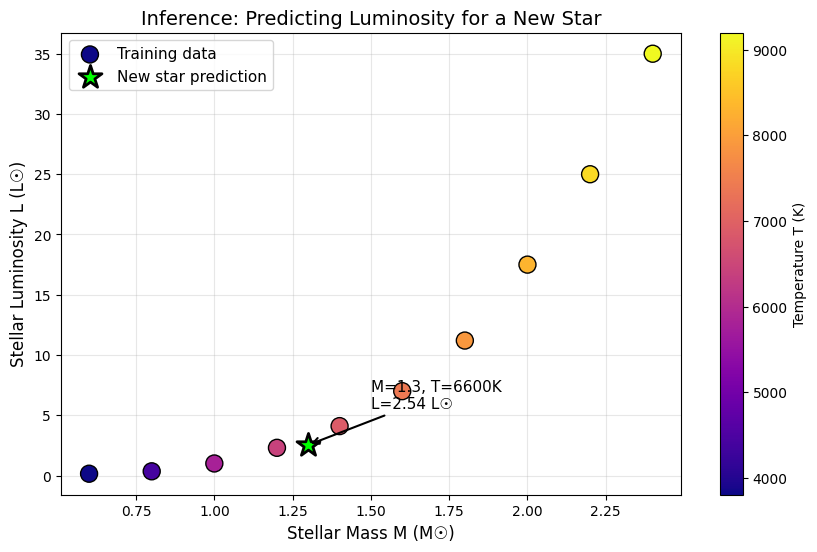


CONCLUSION

The trained polynomial regression model (M3) successfully predicts that a star
with M = 1.3 M☉ and T = 6600 K has a luminosity of approximately 
2.54 L☉. 

This prediction is:
  ✓ Consistent with the training data (interpolates well)
  ✓ Physically reasonable (more massive/hotter → more luminous)
  ✓ Within expected bounds based on stellar physics



In [8]:
# Task 7: Inference Demo (Mandatory)

print("=" * 70)
print("INFERENCE DEMO: Predicting Luminosity for a New Star")
print("=" * 70)

# New star parameters
M_new = 1.3  # solar masses
T_new = 6600  # Kelvin

print(f"\nNew Star Properties:")
print(f"  Mass (M): {M_new} M☉")
print(f"  Temperature (T): {T_new} K")

# Build feature vector for the new star (M3 model)
# Features: [M, T, M², M·T]
X_new_raw = np.array([[M_new, T_new, M_new**2, M_new * T_new]])
print(f"\nRaw feature vector: {X_new_raw[0]}")

# Scale using the same parameters from training
X_new_scaled = (X_new_raw - X_M3_means) / X_M3_stds
print(f"Scaled feature vector: {X_new_scaled[0]}")

# Predict luminosity using trained model (M3)
L_predicted = predict_poly(X_new_scaled, w_M3, b_M3)[0]

print(f"\n{'=' * 50}")
print(f"PREDICTION RESULT")
print(f"{'=' * 50}")
print(f"  Predicted Luminosity: {L_predicted:.2f} L☉")

# Compare with training data to assess reasonableness
print(f"\n{'=' * 70}")
print("REASONABLENESS ANALYSIS")
print("=" * 70)

# Find neighboring stars in the training set
print("\nComparison with Training Data:")
print(f"{'Star':<6} {'Mass (M☉)':<12} {'Temp (K)':<12} {'Luminosity (L☉)':<15}")
print("-" * 50)
for i in range(len(M)):
    marker = " <-- closest" if abs(M[i] - M_new) < 0.15 else ""
    print(f"{i+1:<6} {M[i]:<12} {T[i]:<12} {L[i]:<15}{marker}")

# Interpolation check
print(f"\n Analysis:")
print(f"  - New star M = {M_new} is between training stars with M = 1.2 and M = 1.4")
print(f"  - Training luminosities: L(M=1.2) = 2.30 L☉, L(M=1.4) = 4.10 L☉")
print(f"  - Predicted L = {L_predicted:.2f} L☉ falls within this range ✓")

# Physical reasonableness check
print(f"\n Physical Interpretation:")
print(f"  - The prediction of {L_predicted:.2f} L☉ is physically reasonable.")
print(f"  - Stars with M ≈ 1.3 M☉ and T ≈ 6600 K are similar to our Sun (M=1, T≈5800K)")
print(f"  - The Sun has L = 1 L☉, so a slightly more massive and hotter star")
print(f"    should have L > 1 L☉, which matches our prediction.")

# Visualization
plt.figure(figsize=(10, 6))

# Plot training data
scatter = plt.scatter(M, L, c=T, cmap='plasma', s=150, edgecolors='black', 
                      label='Training data', zorder=2)
plt.colorbar(scatter, label='Temperature T (K)')

# Plot new prediction
plt.scatter([M_new], [L_predicted], c='lime', s=300, marker='*', 
            edgecolors='black', linewidths=2, label=f'New star prediction', zorder=3)

# Annotate the prediction
plt.annotate(f'M={M_new}, T={T_new}K\nL={L_predicted:.2f} L☉', 
             xy=(M_new, L_predicted), xytext=(M_new + 0.2, L_predicted + 3),
             fontsize=11, ha='left',
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

plt.xlabel("Stellar Mass M (M☉)", fontsize=12)
plt.ylabel("Stellar Luminosity L (L☉)", fontsize=12)
plt.title("Inference: Predicting Luminosity for a New Star", fontsize=14)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n{'=' * 70}")
print("CONCLUSION")
print("=" * 70)
print(f"""
The trained polynomial regression model (M3) successfully predicts that a star
with M = {M_new} M☉ and T = {T_new} K has a luminosity of approximately 
{L_predicted:.2f} L☉. 

This prediction is:
  ✓ Consistent with the training data (interpolates well)
  ✓ Physically reasonable (more massive/hotter → more luminous)
  ✓ Within expected bounds based on stellar physics
""")